In [1]:
"""
多因子合成与回测系统
支持线性模型、机器学习、神经网络等多种方法
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import joblib
import multiprocessing as mp
from functools import partial

In [4]:
# ==================== 导入cross_sectional.py中的类 ====================
# 获取当前脚本所在目录.py
# SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
# if SCRIPT_DIR not in sys.path:
#     sys.path.insert(0, SCRIPT_DIR)

# 获取当前工作目录（适用于 Jupyter Notebook / 交互式环境）
SCRIPT_DIR = os.getcwd()

if SCRIPT_DIR not in sys.path:
    sys.path.insert(0, SCRIPT_DIR)

# 从cross_sectional.py导入回测相关类
try:
    from cross_sectional import BacktestEngine, ResultAnalyzer, Config
    print("✅ 成功从 cross_sectional.py 导入 BacktestEngine, ResultAnalyzer, Config")
except ImportError as e:
    print(f"⚠️ 导入失败: {e}")
    print("请确保 cross_sectional.py 文件存在")
    # 如果导入失败，定义本地Config类
    class Config:
        """回测配置"""
        TOP_N = 200
        MAX_TURNOVER = 0.30
        FEE_RATE = 0.0014
        LOT_SIZE = 100
        LOT_SIZE_688 = 200
        LIMIT_UP_10 = 0.095
        LIMIT_DOWN_10 = -0.095
        LIMIT_UP_20 = 0.195
        LIMIT_DOWN_20 = -0.195
        STOCK_POOL = 'all'
        FACTOR_NAME = 'ret_20d'
        BENCHMARK_STOCK = '000002.SZ'

✅ 成功从 cross_sectional.py 导入 BacktestEngine, ResultAnalyzer, Config


In [5]:
# ==================== 配置参数 ====================
class ModelConfig:
    """模型配置"""
    # 数据路径
    DATA_PATH = "../final_data"
    OUTPUT_PATH = "../model_results"
    
    # 训练配置
    TRAIN_WINDOW = 252 * 3  # 训练窗口（交易日），默认3年
    RETRAIN_FREQ = 63  # 重训练频率（交易日），默认每季度（约63个交易日）
    VALIDATION_WINDOW = 63  # 验证窗口
    
    # 标签配置
    LABEL_PERIOD = 1  # 预测周期（交易日）
    
    # 模型选择
    MODEL_TYPE = 'ensemble'  # 'linear', 'ridge', 'lasso', 'elasticnet', 'rf', 'gbdt', 'svr', 'mlp', 'ensemble'
    
    # 特征选择
    USE_FEATURES = 'all'  # 'all' 或指定特征列表
    
    # 多进程配置
    N_JOBS = 4  # 并行进程数，-1表示使用所有核心
    
    # 随机种子
    RANDOM_SEED = 42

In [18]:
# ==================== 数据加载与预处理 ====================
class DataProcessor:
    """数据处理器"""
    
    def __init__(self, data_path=None):
        """
        初始化数据处理器
        
        Parameters:
        -----------
        data_path: str or Path, 数据文件路径（可选）
        """
        if data_path is not None:
            self.data_path = Path(data_path)
        else:
            self.data_path = None
        self.data = None
        self.factor_cols = []
        
    def load_data(self, file_path=None):
        """
        加载数据
        
        Parameters:
        -----------
        file_path: str or Path, 数据文件路径（如果为None，使用self.data_path）
        """
        print("加载数据...")
        
        # 确定文件路径
        if file_path is not None:
            data_path = Path(file_path)
        elif self.data_path is not None:
            data_path = self.data_path
        else:
            raise ValueError("未指定数据路径，请传入file_path或设置data_path")
        
        # 加载CSV文件
        csv_file = data_path / "final_200stocks_with_benchmark_2020_2025.csv"
        parquet_file = data_path / "final_200stocks_with_benchmark_2020_2025.parquet"
        
        print(f"查找CSV文件: {csv_file}")
        print(f"查找Parquet文件: {parquet_file}")
        
        if csv_file.exists():
            print(f"✅ 找到CSV文件: {csv_file}")
            df = pd.read_csv(csv_file)
            df['trade_date'] = pd.to_datetime(df['trade_date'])
            print(f"CSV文件读取成功，形状: {df.shape}")
        elif parquet_file.exists():
            print(f"✅ 找到Parquet文件: {parquet_file}")
            df = pd.read_parquet(parquet_file)
            print(f"Parquet文件读取成功，形状: {df.shape}")
        else:
            print(f"❌ 数据文件不存在")
            print(f"  检查路径: {csv_file}")
            print(f"  检查路径: {parquet_file}")
            raise FileNotFoundError(f"数据文件不存在")
        
        # 识别因子列
        exclude_cols = ['trade_date', 'ts_code', 'symbol', 'name', 'area', 'industry', 'market', 
                       'list_date', 'days_since_listed', 'year', 'month', 'quarter',
                       'open', 'high', 'low', 'close', 'vol', 'amount', 'twap', 
                       'close_adj', 'twap_adj', 'open_adj', 'high_adj', 'low_adj', 'accum_factor']
        
        self.factor_cols = [col for col in df.columns if col not in exclude_cols]
        self.data = df
        
        print(f"数据加载完成，形状: {df.shape}")
        print(f"因子数量: {len(self.factor_cols)}")
        print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
        print(f"股票数量: {df['ts_code'].nunique()}")
        
        return df
    
    def prepare_training_data(self, df, train_dates):
        """准备训练数据"""
        train_df = df[df['trade_date'].isin(train_dates)].copy()
        
        # 按股票分组处理
        X_list = []
        y_list = []
        stock_list = []
        date_list = []
        
        for ts_code, group in train_df.groupby('ts_code'):
            group = group.sort_values('trade_date')
            
            # 获取因子值
            X = group[self.factor_cols].values
            
            # 计算标签：t2价格 / t1价格 - 1
            # 即使用未来第LABEL_PERIOD天的收益率
            future_returns = group['close_adj'].shift(-ModelConfig.LABEL_PERIOD) / group['close_adj'] - 1
            y = future_returns.values
            
            # 去除NaN
            valid_idx = ~(np.isnan(y) | np.isnan(X).any(axis=1))
            
            if valid_idx.sum() > 0:
                X_list.append(X[valid_idx])
                y_list.append(y[valid_idx])
                stock_list.extend([ts_code] * valid_idx.sum())
                date_list.extend(group['trade_date'].values[valid_idx])
        
        if not X_list:
            return None, None, None, None
        
        X_all = np.vstack(X_list)
        y_all = np.concatenate(y_list)
        
        return X_all, y_all, np.array(stock_list), np.array(date_list)
    
    def prepare_prediction_data(self, df, pred_dates):
        """准备预测数据"""
        pred_df = df[df['trade_date'].isin(pred_dates)].copy()
        
        X_list = []
        stock_list = []
        date_list = []
        
        for ts_code, group in pred_df.groupby('ts_code'):
            group = group.sort_values('trade_date')
            
            X = group[self.factor_cols].values
            valid_idx = ~np.isnan(X).any(axis=1)
            
            if valid_idx.sum() > 0:
                X_list.append(X[valid_idx])
                stock_list.extend([ts_code] * valid_idx.sum())
                date_list.extend(group['trade_date'].values[valid_idx])
        
        if not X_list:
            return None, None, None
        
        X_all = np.vstack(X_list)
        
        return X_all, np.array(stock_list), np.array(date_list)

In [7]:
# ==================== 模型训练器 ====================
class ModelTrainer:
    """模型训练器"""
    
    def __init__(self, model_type='linear'):
        self.model_type = model_type
        self.model = None
        self.scaler = StandardScaler()
        self.feature_importance = None
        
    def create_model(self):
        """创建模型"""
        if self.model_type == 'linear':
            return LinearRegression()
        elif self.model_type == 'ridge':
            return Ridge(alpha=1.0)
        elif self.model_type == 'lasso':
            return Lasso(alpha=0.01)
        elif self.model_type == 'elasticnet':
            return ElasticNet(alpha=0.01, l1_ratio=0.5)
        elif self.model_type == 'rf':
            return RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=ModelConfig.RANDOM_SEED,
                n_jobs=-1
            )
        elif self.model_type == 'gbdt':
            return GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=ModelConfig.RANDOM_SEED
            )
        elif self.model_type == 'svr':
            return SVR(kernel='rbf', C=1.0, epsilon=0.1)
        elif self.model_type == 'mlp':
            return MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=ModelConfig.RANDOM_SEED,
                early_stopping=True
            )
        else:
            raise ValueError(f"不支持的模型类型: {self.model_type}")
    
    def train(self, X_train, y_train, X_val=None, y_val=None):
        """训练模型"""
        # 标准化
        X_train_scaled = self.scaler.fit_transform(X_train)
        
        if X_val is not None:
            X_val_scaled = self.scaler.transform(X_val)
        
        # 创建并训练模型
        self.model = self.create_model()
        self.model.fit(X_train_scaled, y_train)
        
        # 计算特征重要性
        if hasattr(self.model, 'feature_importances_'):
            self.feature_importance = self.model.feature_importances_
        elif hasattr(self.model, 'coef_'):
            self.feature_importance = np.abs(self.model.coef_)
        
        # 评估
        train_pred = self.model.predict(X_train_scaled)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        train_r2 = r2_score(y_train, train_pred)
        
        print(f"训练集 RMSE: {train_rmse:.6f}, R2: {train_r2:.4f}")
        
        if X_val is not None:
            val_pred = self.model.predict(X_val_scaled)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            val_r2 = r2_score(y_val, val_pred)
            print(f"验证集 RMSE: {val_rmse:.6f}, R2: {val_r2:.4f}")
            
            return {
                'train_rmse': train_rmse,
                'train_r2': train_r2,
                'val_rmse': val_rmse,
                'val_r2': val_r2
            }
        
        return {'train_rmse': train_rmse, 'train_r2': train_r2}
    
    def predict(self, X):
        """预测"""
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

In [19]:
# ==================== 滚动预测框架 ====================
class RollingPredictor:
    """滚动预测器"""
    
    def __init__(self, data, model_type='linear', n_jobs=1):
        self.data = data
        self.model_type = model_type
        self.n_jobs = n_jobs
        
        # 不再创建新的DataProcessor，而是直接使用传入的data
        # 识别因子列
        self.factor_cols = [col for col in data.columns if col not in 
                           ['trade_date', 'ts_code', 'symbol', 'name', 'area', 
                            'industry', 'market', 'list_date', 'days_since_listed', 
                            'year', 'month', 'quarter', 'open', 'high', 'low', 
                            'close', 'vol', 'amount', 'twap', 'close_adj', 
                            'twap_adj', 'open_adj', 'high_adj', 'low_adj', 'accum_factor']]
        
        self.predictions = {}
        self.models = {}
        self.model_results = []
        
    def prepare_training_data(self, train_dates):
        """准备训练数据"""
        train_df = self.data[self.data['trade_date'].isin(train_dates)].copy()
        
        # 按股票分组处理
        X_list = []
        y_list = []
        stock_list = []
        date_list = []
        
        for ts_code, group in train_df.groupby('ts_code'):
            group = group.sort_values('trade_date')
            
            # 获取因子值
            X = group[self.factor_cols].values
            
            # 计算标签
            future_returns = group['close_adj'].shift(-ModelConfig.LABEL_PERIOD) / group['close_adj'] - 1
            y = future_returns.values
            
            # 去除NaN
            valid_idx = ~(np.isnan(y) | np.isnan(X).any(axis=1))
            
            if valid_idx.sum() > 0:
                X_list.append(X[valid_idx])
                y_list.append(y[valid_idx])
                stock_list.extend([ts_code] * valid_idx.sum())
                date_list.extend(group['trade_date'].values[valid_idx])
        
        if not X_list:
            return None, None, None, None
        
        X_all = np.vstack(X_list)
        y_all = np.concatenate(y_list)
        
        return X_all, y_all, np.array(stock_list), np.array(date_list)
    
    def prepare_prediction_data(self, pred_dates):
        """准备预测数据"""
        pred_df = self.data[self.data['trade_date'].isin(pred_dates)].copy()
        
        X_list = []
        stock_list = []
        date_list = []
        
        for ts_code, group in pred_df.groupby('ts_code'):
            group = group.sort_values('trade_date')
            
            X = group[self.factor_cols].values
            valid_idx = ~np.isnan(X).any(axis=1)
            
            if valid_idx.sum() > 0:
                X_list.append(X[valid_idx])
                stock_list.extend([ts_code] * valid_idx.sum())
                date_list.extend(group['trade_date'].values[valid_idx])
        
        if not X_list:
            return None, None, None
        
        X_all = np.vstack(X_list)
        
        return X_all, np.array(stock_list), np.array(date_list)
    
    def rolling_train_predict(self):
        """滚动训练和预测"""
        print(f"\n开始滚动预测...")
        print(f"模型类型: {self.model_type}")
        print(f"训练窗口: {ModelConfig.TRAIN_WINDOW} 天")
        print(f"重训练频率: {ModelConfig.RETRAIN_FREQ} 天")
        print(f"因子数量: {len(self.factor_cols)}")
        
        # 获取所有日期
        all_dates = sorted(self.data['trade_date'].unique())
        print(f"总交易日: {len(all_dates)}")
        
        # 检查是否有足够的数据
        if len(all_dates) < ModelConfig.TRAIN_WINDOW + 10:
            print(f"⚠️ 数据不足: 需要至少 {ModelConfig.TRAIN_WINDOW + 10} 个交易日，当前只有 {len(all_dates)} 个")
            return pd.DataFrame()
        
        # 初始化
        pred_results = []
        total_predictions = 0
        
        # 滚动训练
        for i in range(ModelConfig.TRAIN_WINDOW, len(all_dates) - ModelConfig.LABEL_PERIOD, ModelConfig.RETRAIN_FREQ):
            # 训练日期
            train_dates = all_dates[i - ModelConfig.TRAIN_WINDOW:i]
            
            # 预测日期
            pred_date = all_dates[i]
            
            print(f"\n训练窗口: {train_dates[0]} 到 {train_dates[-1]}")
            print(f"预测日期: {pred_date}")
            
            # 准备训练数据
            X_train, y_train, _, _ = self.prepare_training_data(train_dates)
            
            if X_train is None or len(X_train) < 100:
                print(f"训练数据不足 (样本数: {0 if X_train is None else len(X_train)})，跳过 {pred_date}")
                continue
            
            print(f"训练样本数: {len(X_train)}")
            
            # 划分训练集和验证集
            split_idx = int(len(X_train) * 0.8)
            X_tr, X_val = X_train[:split_idx], X_train[split_idx:]
            y_tr, y_val = y_train[:split_idx], y_train[split_idx:]
            
            # 训练模型
            trainer = ModelTrainer(self.model_type)
            metrics = trainer.train(X_tr, y_tr, X_val, y_val)
            
            # 保存模型
            self.models[pred_date] = trainer
            
            # 准备预测数据
            X_pred, stock_list, date_list = self.prepare_prediction_data([pred_date])
            
            if X_pred is None or len(X_pred) == 0:
                print(f"无预测数据，跳过 {pred_date}")
                continue
            
            # 预测
            y_pred = trainer.predict(X_pred)
            
            # 保存预测结果
            for j, (stock, date, pred) in enumerate(zip(stock_list, date_list, y_pred)):
                pred_results.append({
                    'trade_date': date,
                    'ts_code': stock,
                    'pred_score': pred,
                    'model_type': self.model_type
                })
            
            total_predictions += len(X_pred)
            
            # 记录模型结果
            self.model_results.append({
                'train_date': train_dates[-1],
                'pred_date': pred_date,
                'train_size': len(X_train),
                'predictions': len(X_pred),
                'metrics': metrics
            })
            
            print(f"预测完成，共 {len(X_pred)} 个样本")
        
        # 保存预测结果
        self.predictions = pd.DataFrame(pred_results)
        print(f"\n滚动预测完成，共 {total_predictions} 个预测结果")
        
        if self.predictions.empty:
            print("⚠️ 没有生成任何预测结果")
        else:
            print(f"预测结果形状: {self.predictions.shape}")
            print(f"预测日期范围: {self.predictions['trade_date'].min()} 到 {self.predictions['trade_date'].max()}")
        
        return self.predictions

In [9]:
# ==================== 因子合成与回测 ====================
class FactorCombiner:
    """因子合成器"""
    
    def __init__(self, data, predictions):
        self.data = data
        self.predictions = predictions
        
    def combine_factors(self):
        """合成因子"""
        print("\n合成因子...")
        
        # 合并预测结果到原始数据
        combined = self.data.merge(
            self.predictions[['trade_date', 'ts_code', 'pred_score']],
            on=['trade_date', 'ts_code'],
            how='left'
        )
        
        # 填充缺失值（使用滚动平均填充）
        combined['pred_score'] = combined.groupby('ts_code')['pred_score'].transform(
            lambda x: x.fillna(x.rolling(10, min_periods=1).mean())
        )
        
        # 前向填充
        combined['pred_score'] = combined.groupby('ts_code')['pred_score'].ffill()
        
        # 标准化合成因子（横截面标准化）
        def cross_section_standardize(group):
            mean = group.mean()
            std = group.std()
            if std > 0:
                return (group - mean) / std
            return group
        
        combined['composite_factor'] = combined.groupby('trade_date')['pred_score'].transform(
            cross_section_standardize
        )
        
        print(f"合成因子完成，形状: {combined.shape}")
        print(f"合成因子统计: 均值={combined['composite_factor'].mean():.4f}, "
              f"标准差={combined['composite_factor'].std():.4f}")
        
        return combined


In [10]:
# ==================== 回测引擎（适配复合因子 - 使用cross_sectional中的BacktestEngine） ====================
class CompositeFactorBacktest:
    """复合因子回测引擎 - 使用cross_sectional.py中的BacktestEngine"""
    
    def __init__(self, data, factor_name='composite_factor'):
        """
        初始化
        
        Parameters:
        -----------
        data: DataFrame, 包含所有数据的DataFrame（包含复合因子列）
        factor_name: str, 复合因子的列名
        """
        self.data = data
        self.factor_name = factor_name
        self.results = {}
        self.engine = None
        self.analyzer = None
        self.metrics = None
        
    def prepare_data_for_engine(self, config):
        """
        准备BacktestEngine需要的数据格式
        
        Parameters:
        -----------
        config: Config对象, 回测配置（来自cross_sectional.py）
        """
        backtest_data = self.data.copy()
        
        # 获取股票信息
        stock_info = backtest_data[['ts_code', 'symbol', 'name', 'industry']].drop_duplicates('ts_code')
        
        # 获取基准数据
        benchmark_stock = getattr(config, 'BENCHMARK_STOCK', stock_info['ts_code'].iloc[0])
        benchmark_df = backtest_data[backtest_data['ts_code'] == benchmark_stock].copy()
        if benchmark_df.empty:
            benchmark_stock = stock_info['ts_code'].iloc[0]
            benchmark_df = backtest_data[backtest_data['ts_code'] == benchmark_stock].copy()
        
        # 获取价格数据
        price_data = backtest_data.pivot(index='trade_date', columns='ts_code', values='close_adj')
        twap_data = backtest_data.pivot(index='trade_date', columns='ts_code', values='twap_adj')
        accum_factor = backtest_data.pivot(index='trade_date', columns='ts_code', values='accum_factor')
        
        # 构建因子数据字典（包含复合因子）
        factor_data = {
            self.factor_name: backtest_data.pivot(index='trade_date', columns='ts_code', values=self.factor_name)
        }
        
        # 获取ST标识
        st_data = backtest_data[['trade_date', 'ts_code', 'name']].copy()
        st_data['is_st'] = st_data['name'].str.contains('ST|\\*ST', case=False, na=False)
        st_pivot = st_data.pivot(index='trade_date', columns='ts_code', values='is_st').fillna(False)
        
        return {
            'df': backtest_data,
            'stock_info': stock_info,
            'benchmark': benchmark_df,
            'benchmark_stock': benchmark_stock,
            'price': price_data,
            'twap': twap_data,
            'accum_factor': accum_factor,
            'factors': factor_data,
            'st': st_pivot,
            'factor_cols': [self.factor_name]
        }
        
    def run_backtest(self, config):
        """
        运行回测 - 使用cross_sectional.py中的BacktestEngine
        
        Parameters:
        -----------
        config: Config对象, 回测配置（来自cross_sectional.py）
        """
        print(f"\n" + "="*80)
        print(f"使用复合因子进行回测: {self.factor_name}")
        print("="*80)
        
        # 准备数据
        data_for_engine = self.prepare_data_for_engine(config)
        
        # 使用cross_sectional.py中的BacktestEngine
        self.engine = BacktestEngine(data_for_engine, config)
        
        # 运行回测（使用复合因子）
        results = self.engine.run(factor_name=self.factor_name)
        
        # 保存结果
        self.results = results
        
        # 分析结果 - 使用cross_sectional.py中的ResultAnalyzer
        self.analyzer = ResultAnalyzer(
            self.engine, 
            data_for_engine['benchmark'], 
            data_for_engine['benchmark_stock']
        )
        self.metrics = self.analyzer.analyze()
        
        return results
    
    def get_performance_metrics(self):
        """获取绩效指标"""
        if self.metrics is not None:
            return self.metrics
        return None
    
    def plot_results(self, save_path=None):
        """绘制结果图"""
        if self.analyzer is not None:
            return self.analyzer.plot_results(save_path)
        return None
    
    def save_results(self, output_dir):
        """保存结果"""
        if self.analyzer is not None:
            return self.analyzer.save_results(output_dir)
        return None
    
    def get_trade_records(self):
        """获取交易记录"""
        if self.engine is not None:
            return pd.DataFrame(self.engine.trade_records)
        return None
    
    def get_daily_holdings(self):
        """获取每日持仓"""
        if self.engine is not None:
            return pd.DataFrame(self.engine.daily_holdings)
        return None
    
    def get_daily_nav(self):
        """获取每日净值"""
        if self.engine is not None:
            nav_df = pd.DataFrame({
                'date': list(self.engine.portfolio_value.keys()),
                'total_value': list(self.engine.portfolio_value.values()),
                'cash': list(self.engine.cash.values())
            })
            return nav_df
        return None


In [11]:
# ==================== 结果分析与对比 ====================
class ResultComparator:
    """结果对比分析器"""
    
    def __init__(self, results_dict):
        self.results = results_dict
        
    def compare(self):
        """对比不同模型的结果"""
        print("\n" + "="*80)
        print("模型对比分析")
        print("="*80)
        
        comparison = []
        
        for model_name, result in self.results.items():
            if result is None:
                continue
                
            metrics = self.calculate_metrics(result)
            metrics['model'] = model_name
            comparison.append(metrics)
        
        if not comparison:
            print("没有可对比的结果")
            return None
        
        df = pd.DataFrame(comparison)
        df.set_index('model', inplace=True)
        
        print("\n模型对比:")
        print(df.round(4))
        
        return df
    
    def calculate_metrics(self, result):
        """计算绩效指标"""
        # 处理不同的结果格式
        if 'portfolio_value' in result:
            portfolio_values = pd.Series(result['portfolio_value']).sort_index()
        else:
            return {'total_return': 0, 'annual_return': 0, 'sharpe': 0, 'max_drawdown': 0}
        
        returns = portfolio_values.pct_change().dropna()
        
        if len(returns) == 0:
            return {'total_return': 0, 'annual_return': 0, 'sharpe': 0, 'max_drawdown': 0}
        
        total_return = (1 + returns).prod() - 1
        days = len(returns)
        years = days / 252
        annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
        annual_vol = returns.std() * np.sqrt(252) if len(returns) > 1 else 0
        sharpe = (annual_return - 0.03) / annual_vol if annual_vol > 0 else 0
        
        cum_returns = (1 + returns).cumprod()
        running_max = cum_returns.expanding().max()
        drawdown = (cum_returns / running_max - 1)
        max_drawdown = drawdown.min()
        
        return {
            'total_return': total_return,
            'annual_return': annual_return,
            'annual_volatility': annual_vol,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'trading_days': days
        }

In [15]:
# ==================== 修改使用示例函数 ====================
def run_composite_factor_backtest(combined_data, factor_name='composite_factor', output_dir=None):
    """
    运行复合因子回测
    
    Parameters:
    -----------
    combined_data: DataFrame, 包含复合因子的数据
    factor_name: str, 复合因子列名
    output_dir: str, 输出目录（可选）
    """
    # 如果没有指定输出目录，使用默认目录
    if output_dir is None:
        current_dir = os.getcwd()
        output_dir = os.path.join(current_dir, 'composite_result')
    
    os.makedirs(output_dir, exist_ok=True)
    
    # 配置回测 - 使用cross_sectional.py中的Config
    try:
        from cross_sectional import Config
    except ImportError:
        # 如果导入失败，使用本地Config
        class Config:
            TOP_N = 200
            MAX_TURNOVER = 0.30
            FEE_RATE = 0.0014
            LOT_SIZE = 100
            LOT_SIZE_688 = 200
            LIMIT_UP_10 = 0.095
            LIMIT_DOWN_10 = -0.095
            LIMIT_UP_20 = 0.195
            LIMIT_DOWN_20 = -0.195
            STOCK_POOL = 'all'
            FACTOR_NAME = 'ret_20d'
            BENCHMARK_STOCK = '000002.SZ'
    
    config = Config()
    config.TOP_N = 200
    config.MAX_TURNOVER = 0.30
    config.FEE_RATE = 0.0014
    config.FACTOR_NAME = factor_name
    config.BENCHMARK_STOCK = '000002.SZ'
    
    # 创建回测实例
    backtest = CompositeFactorBacktest(combined_data, factor_name)
    
    # 运行回测
    results = backtest.run_backtest(config)
    
    # 获取绩效指标
    metrics = backtest.get_performance_metrics()
    
    print("\n" + "="*80)
    print("复合因子回测结果")
    print("="*80)
    
    if metrics:
        print("\n策略绩效:")
        for key, value in metrics['portfolio_metrics'].items():
            if 'Rate' in key or 'Return' in key or 'Drawdown' in key:
                print(f"  {key}: {value:.2%}")
            else:
                print(f"  {key}: {value:.4f}")
        
        print("\n基准绩效:")
        for key, value in metrics['benchmark_metrics'].items():
            if 'Rate' in key or 'Return' in key or 'Drawdown' in key:
                print(f"  {key}: {value:.2%}")
            else:
                print(f"  {key}: {value:.4f}")
        
        print("\n超额收益:")
        for key, value in metrics['excess_metrics'].items():
            if 'Rate' in key or 'Return' in key or 'Drawdown' in key:
                print(f"  {key}: {value:.2%}")
            else:
                print(f"  {key}: {value:.4f}")
    
    # 保存结果
    try:
        backtest.save_results(output_dir)
    except Exception as e:
        print(f"保存结果失败: {e}")
    
    # 保存交易记录
    trade_records = backtest.get_trade_records()
    if trade_records is not None and not trade_records.empty:
        trade_records.to_csv(os.path.join(output_dir, 'composite_trade_records.csv'), index=False)
        print(f"\n交易记录已保存: {os.path.join(output_dir, 'composite_trade_records.csv')}")
        print(f"总交易次数: {len(trade_records)}")
    
    # 保存每日持仓
    daily_holdings = backtest.get_daily_holdings()
    if daily_holdings is not None and not daily_holdings.empty:
        daily_holdings.to_csv(os.path.join(output_dir, 'composite_daily_holdings.csv'), index=False)
        print(f"每日持仓已保存: {os.path.join(output_dir, 'composite_daily_holdings.csv')}")
    
    # 保存每日净值
    daily_nav = backtest.get_daily_nav()
    if daily_nav is not None and not daily_nav.empty:
        daily_nav.to_csv(os.path.join(output_dir, 'composite_daily_nav.csv'), index=False)
        print(f"每日净值已保存: {os.path.join(output_dir, 'composite_daily_nav.csv')}")
    
    # 绘制图表
    try:
        plot_path = os.path.join(output_dir, f'{factor_name}_backtest_results.png')
        backtest.plot_results(save_path=plot_path)
    except Exception as e:
        print(f"绘制图表失败: {e}")
    
    print("\n" + "="*80)
    print(f"所有结果已保存至: {output_dir}")
    print("="*80)
    
    return backtest

多因子合成与回测系统
当前工作目录: d:\a111111\回测模拟\data_process
数据路径: d:\a111111\回测模拟\final_data
输出路径: d:\a111111\回测模拟\data_process\model_results
正在加载数据...
加载数据...
查找CSV文件: d:\a111111\回测模拟\final_data\final_200stocks_with_benchmark_2020_2025.csv
查找Parquet文件: d:\a111111\回测模拟\final_data\final_200stocks_with_benchmark_2020_2025.parquet
✅ 找到CSV文件: d:\a111111\回测模拟\final_data\final_200stocks_with_benchmark_2020_2025.csv
CSV文件读取成功，形状: (236238, 79)
数据加载完成，形状: (236238, 79)
因子数量: 54
日期范围: 2020-04-03 00:00:00 到 2025-12-31 00:00:00
股票数量: 189
✅ 数据加载成功，形状: (236238, 79)
可用因子数量: 54
因子列 (前10个): ['pre_close', 'change', 'pct_chg', 'daily_ret', 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'ma_5']...
数据总行数: 236,238
股票数量: 189
日期范围: 2020-04-03 00:00:00 到 2025-12-31 00:00:00
将测试的模型: ['linear', 'ridge', 'lasso', 'rf', 'gbdt']

测试模型: linear
开始 linear 滚动预测...

开始滚动预测...
模型类型: linear
训练窗口: 756 天
重训练频率: 63 天
因子数量: 54
总交易日: 1395

训练窗口: 2020-04-03 00:00:00 到 2023-05-17 00:00:00
预测日期: 2023-05-18 00:00:00
训练样本数: 116659
训练集 RMS

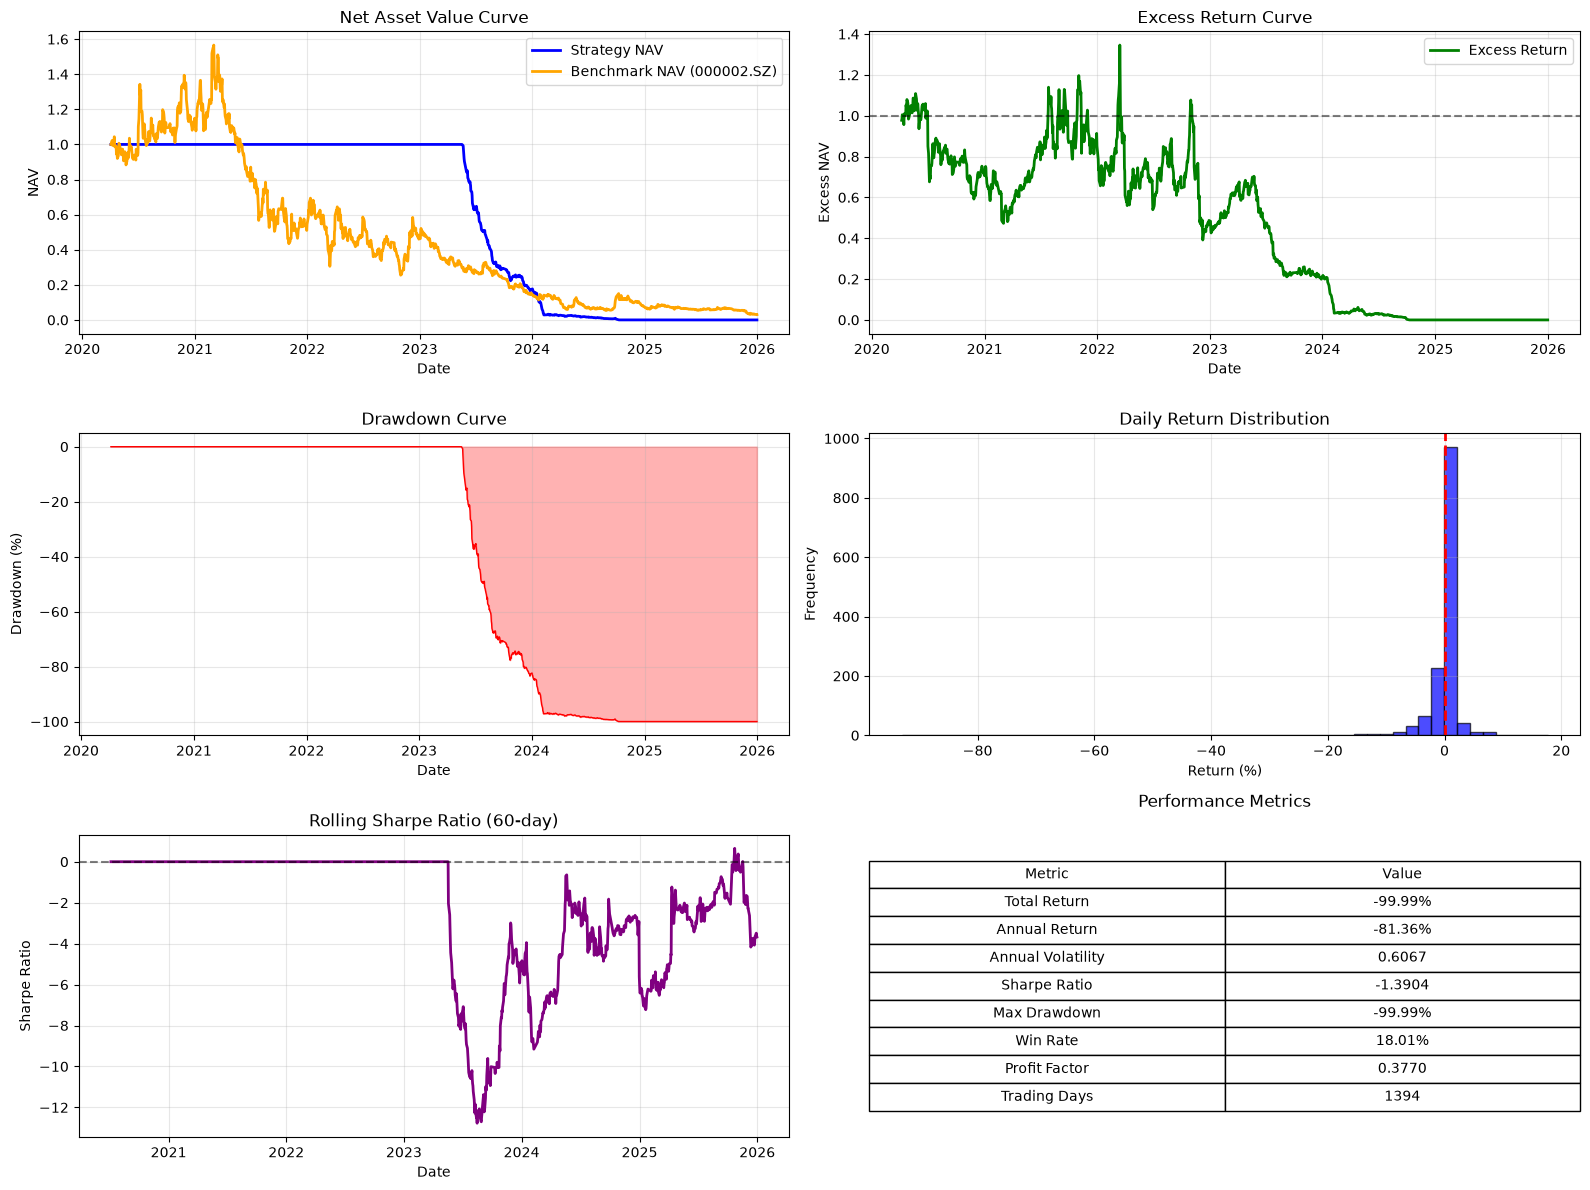


交易记录已保存: d:\a111111\回测模拟\data_process\model_results\linear\composite_trade_records.csv
总交易次数: 1821
每日持仓已保存: d:\a111111\回测模拟\data_process\model_results\linear\composite_daily_holdings.csv
每日净值已保存: d:\a111111\回测模拟\data_process\model_results\linear\composite_daily_nav.csv
图表已保存: d:\a111111\回测模拟\data_process\model_results\linear\composite_factor_backtest_results.png


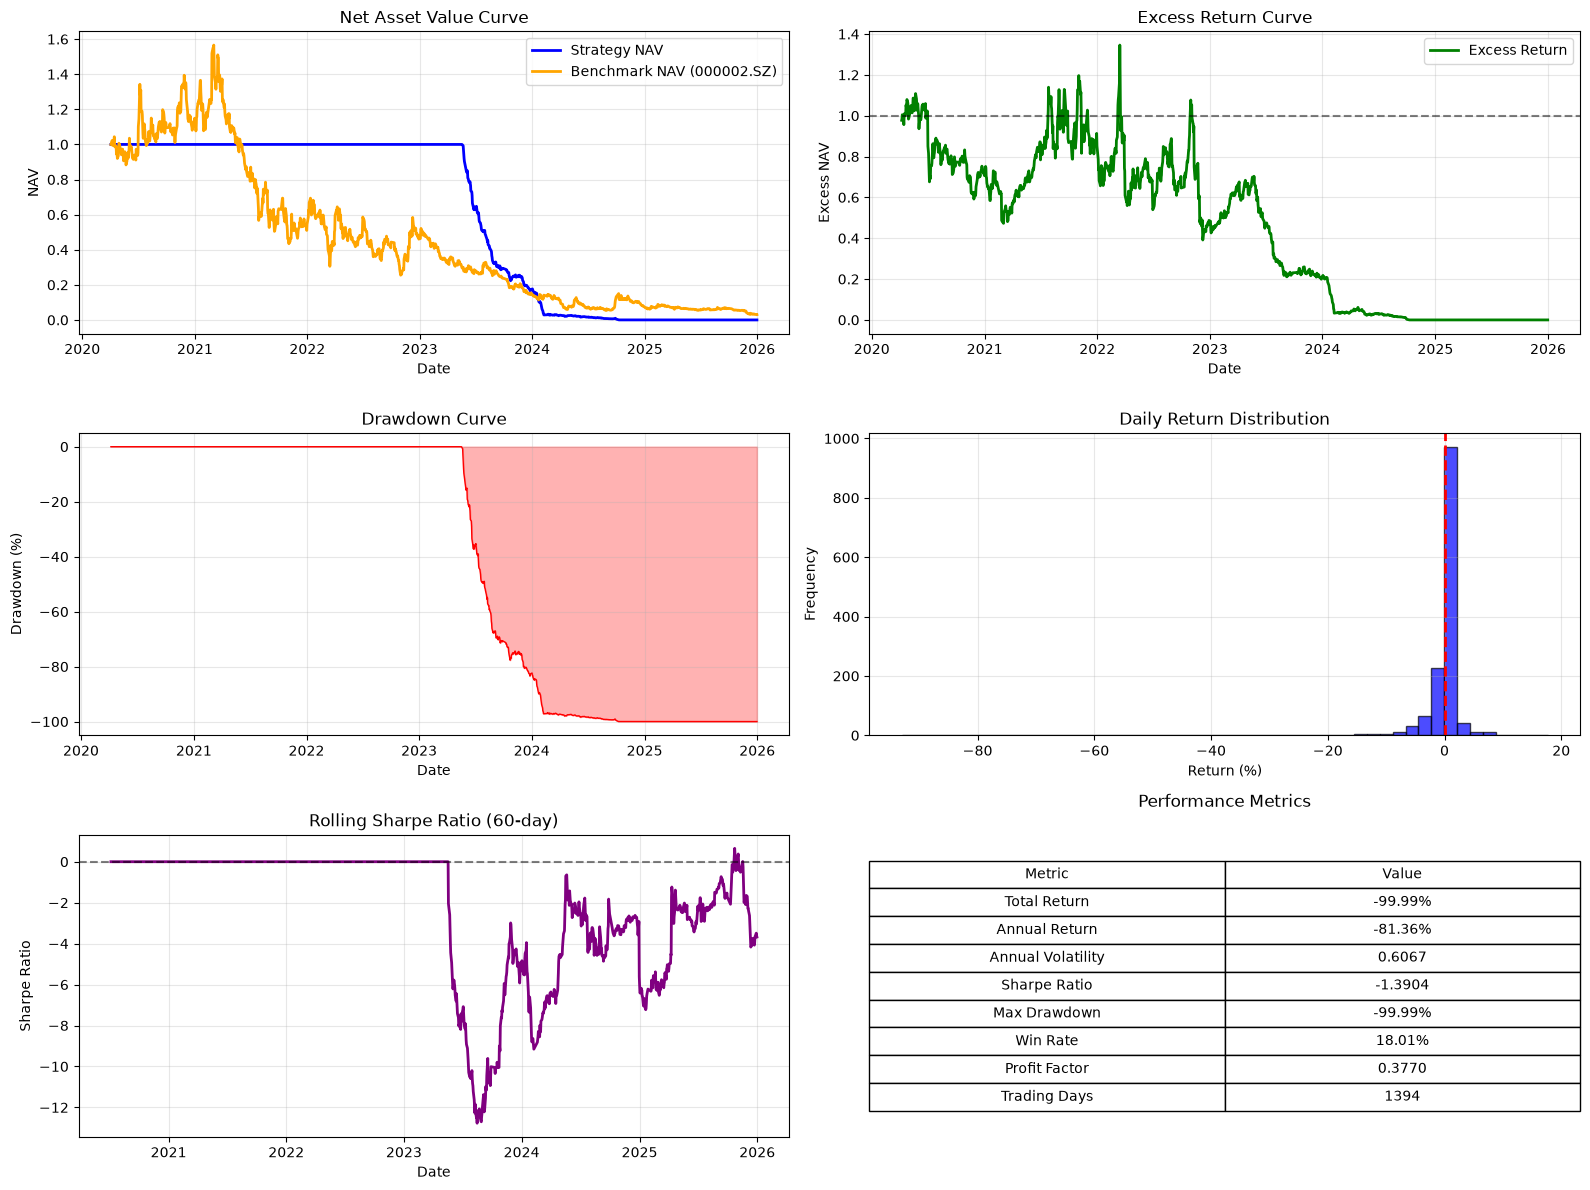


所有结果已保存至: d:\a111111\回测模拟\data_process\model_results\linear
✅ 回测完成

测试模型: ridge
开始 ridge 滚动预测...

开始滚动预测...
模型类型: ridge
训练窗口: 756 天
重训练频率: 63 天
因子数量: 54
总交易日: 1395

训练窗口: 2020-04-03 00:00:00 到 2023-05-17 00:00:00
预测日期: 2023-05-18 00:00:00
训练样本数: 116659
训练集 RMSE: 0.060535, R2: 0.0096
验证集 RMSE: 0.083810, R2: -0.0465
预测完成，共 180 个样本

训练窗口: 2020-07-09 00:00:00 到 2023-08-16 00:00:00
预测日期: 2023-08-17 00:00:00
训练样本数: 119590
训练集 RMSE: 0.059619, R2: 0.0092
验证集 RMSE: 0.083217, R2: -0.0370
预测完成，共 181 个样本

训练窗口: 2020-10-14 00:00:00 到 2023-11-21 00:00:00
预测日期: 2023-11-22 00:00:00
训练样本数: 122600
训练集 RMSE: 0.058258, R2: 0.0091
验证集 RMSE: 0.082970, R2: -0.0412
预测完成，共 186 个样本

训练窗口: 2021-01-12 00:00:00 到 2024-02-27 00:00:00
预测日期: 2024-02-28 00:00:00
训练样本数: 125629
训练集 RMSE: 0.058650, R2: 0.0127
验证集 RMSE: 0.080536, R2: -0.0250
预测完成，共 187 个样本

训练窗口: 2021-04-19 00:00:00 到 2024-05-31 00:00:00
预测日期: 2024-06-03 00:00:00
训练样本数: 128405
训练集 RMSE: 0.058801, R2: 0.0120
验证集 RMSE: 0.079971, R2: -0.0130
预测完成，共 188 个样本


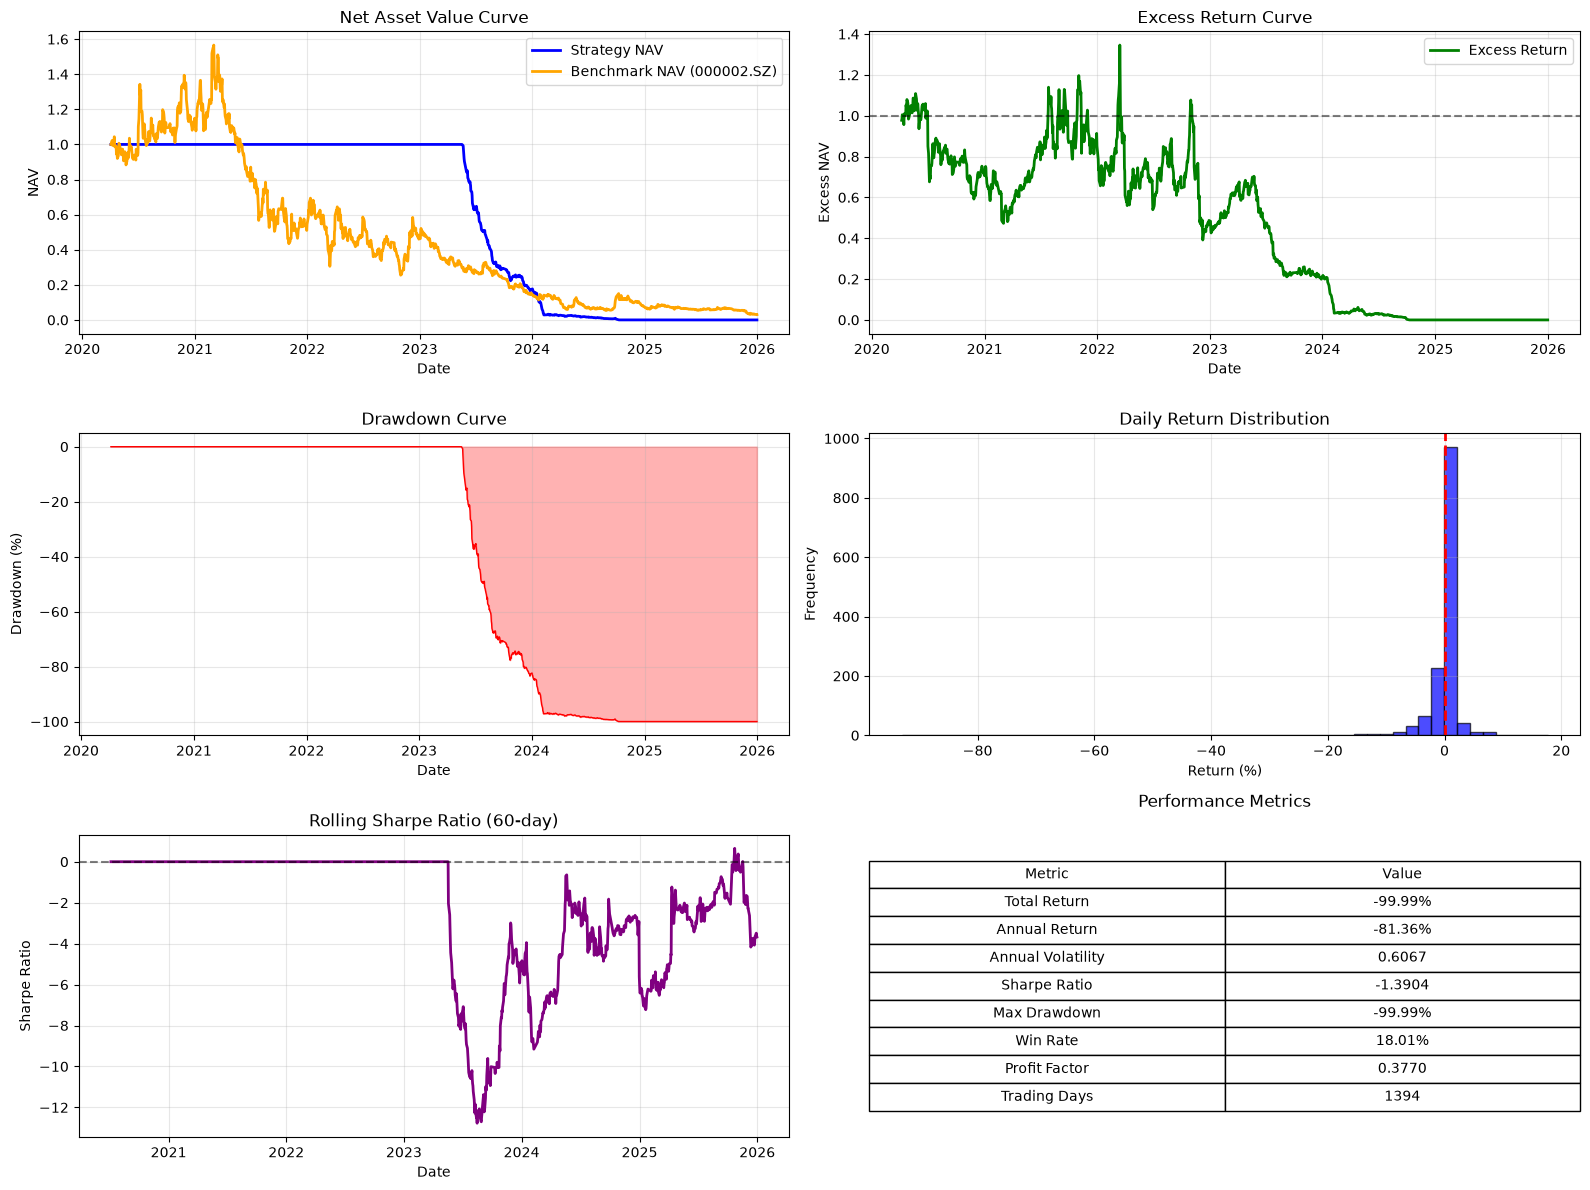


交易记录已保存: d:\a111111\回测模拟\data_process\model_results\ridge\composite_trade_records.csv
总交易次数: 1821
每日持仓已保存: d:\a111111\回测模拟\data_process\model_results\ridge\composite_daily_holdings.csv
每日净值已保存: d:\a111111\回测模拟\data_process\model_results\ridge\composite_daily_nav.csv
图表已保存: d:\a111111\回测模拟\data_process\model_results\ridge\composite_factor_backtest_results.png


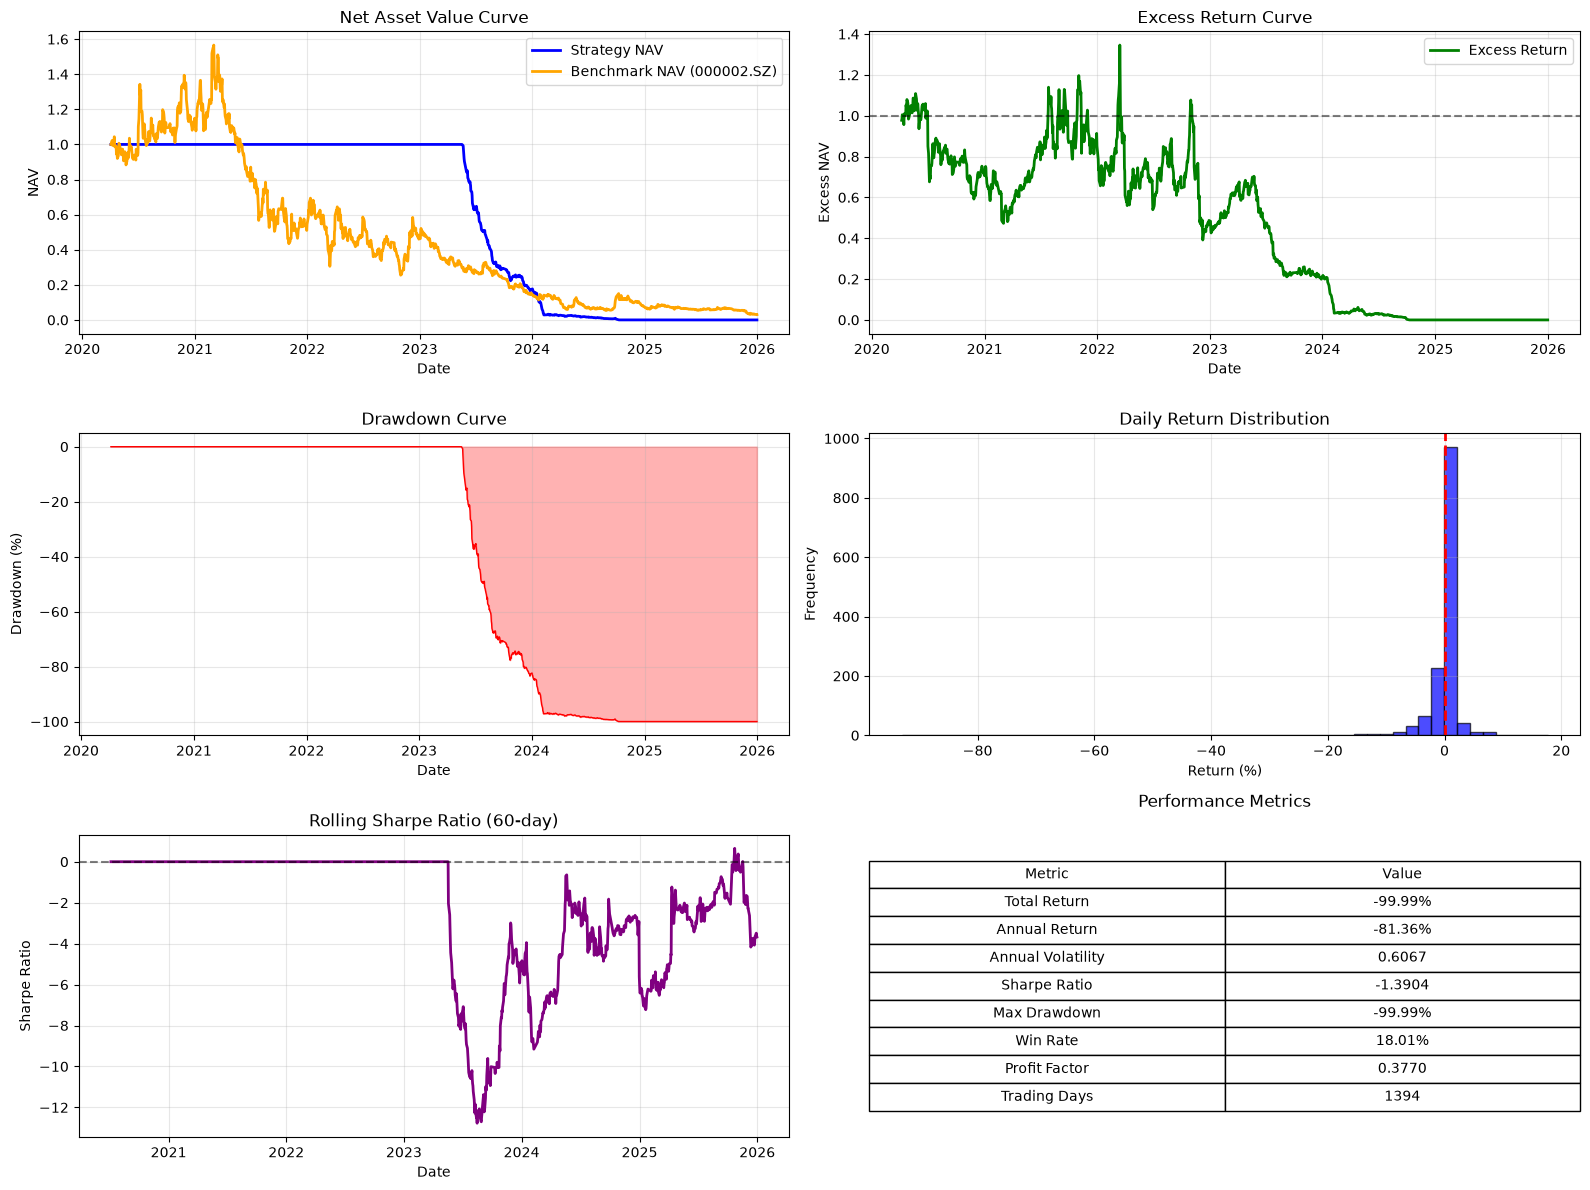


所有结果已保存至: d:\a111111\回测模拟\data_process\model_results\ridge
✅ 回测完成

测试模型: lasso
开始 lasso 滚动预测...

开始滚动预测...
模型类型: lasso
训练窗口: 756 天
重训练频率: 63 天
因子数量: 54
总交易日: 1395

训练窗口: 2020-04-03 00:00:00 到 2023-05-17 00:00:00
预测日期: 2023-05-18 00:00:00
训练样本数: 116659
训练集 RMSE: 0.060828, R2: 0.0000
验证集 RMSE: 0.081927, R2: -0.0000
预测完成，共 180 个样本

训练窗口: 2020-07-09 00:00:00 到 2023-08-16 00:00:00
预测日期: 2023-08-17 00:00:00
训练样本数: 119590
训练集 RMSE: 0.059895, R2: 0.0000
验证集 RMSE: 0.081719, R2: -0.0000
预测完成，共 181 个样本

训练窗口: 2020-10-14 00:00:00 到 2023-11-21 00:00:00
预测日期: 2023-11-22 00:00:00
训练样本数: 122600
训练集 RMSE: 0.058524, R2: 0.0000
验证集 RMSE: 0.081318, R2: -0.0001
预测完成，共 186 个样本

训练窗口: 2021-01-12 00:00:00 到 2024-02-27 00:00:00
预测日期: 2024-02-28 00:00:00
训练样本数: 125629
训练集 RMSE: 0.059027, R2: 0.0000
验证集 RMSE: 0.079550, R2: -0.0001
预测完成，共 187 个样本

训练窗口: 2021-04-19 00:00:00 到 2024-05-31 00:00:00
预测日期: 2024-06-03 00:00:00
训练样本数: 128405
训练集 RMSE: 0.059157, R2: 0.0000
验证集 RMSE: 0.079459, R2: -0.0000
预测完成，共 188 个样本



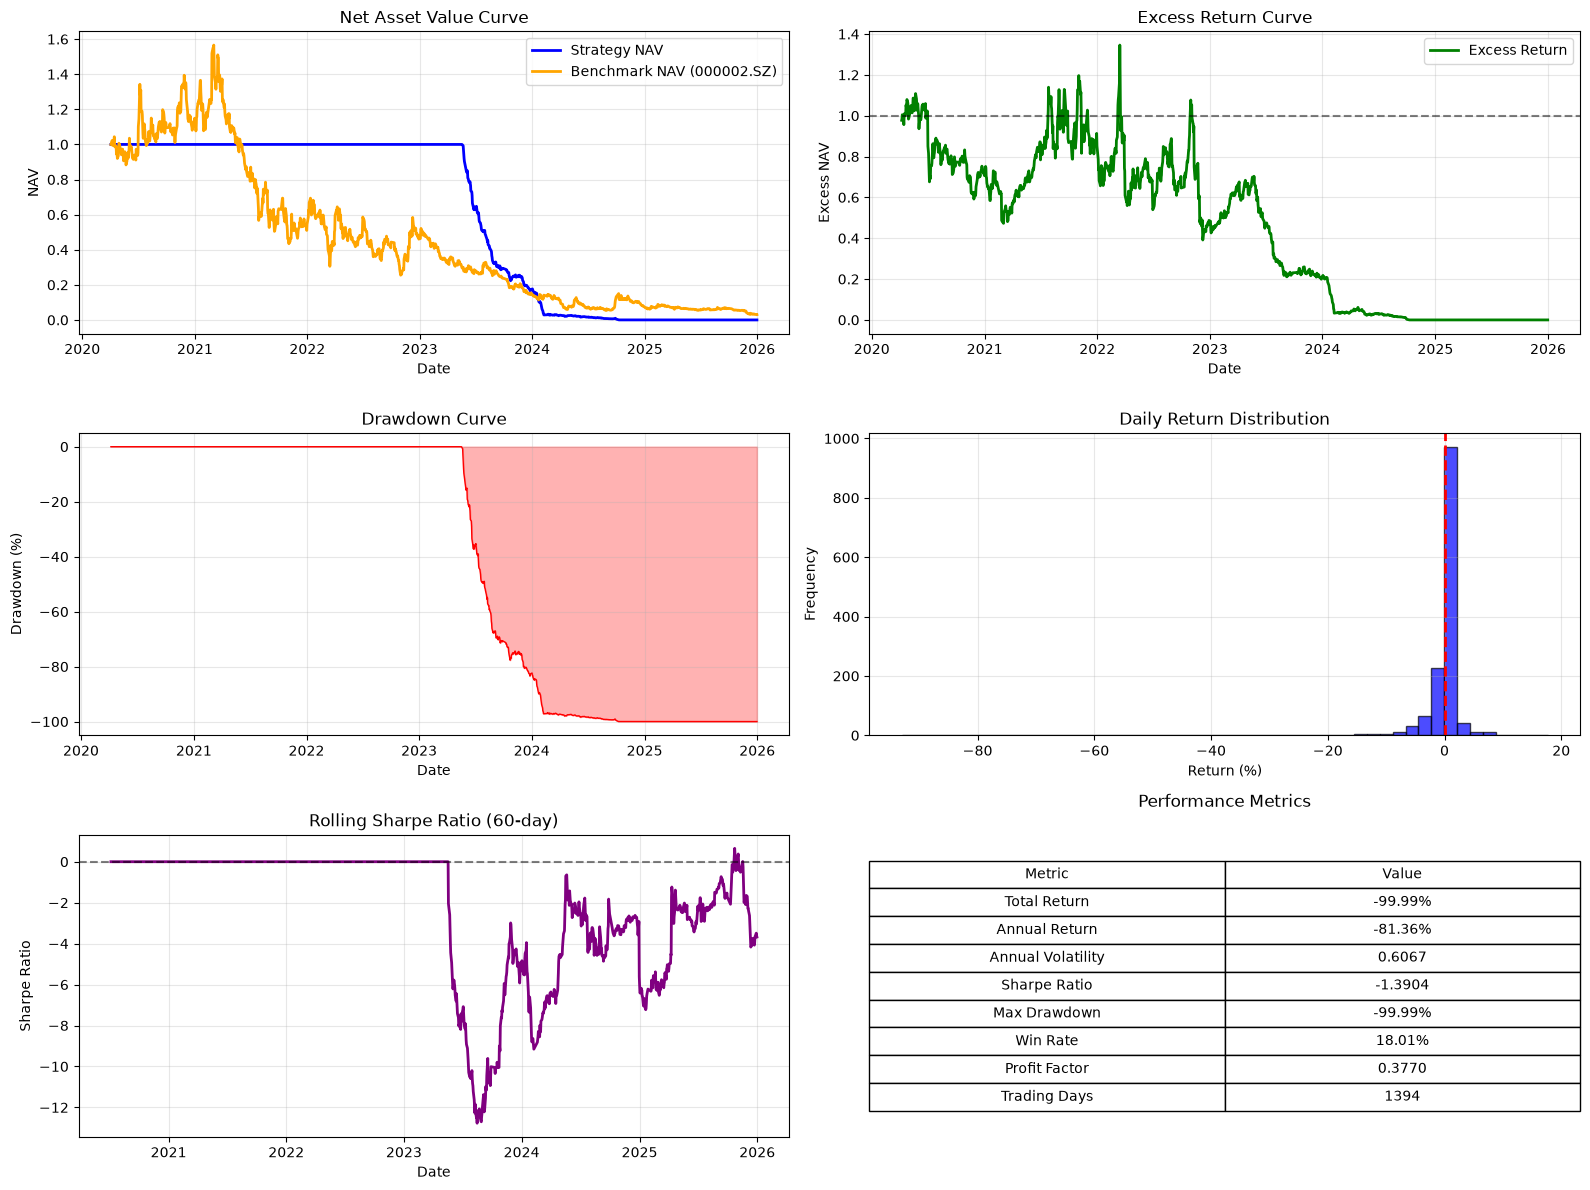


交易记录已保存: d:\a111111\回测模拟\data_process\model_results\lasso\composite_trade_records.csv
总交易次数: 1821
每日持仓已保存: d:\a111111\回测模拟\data_process\model_results\lasso\composite_daily_holdings.csv
每日净值已保存: d:\a111111\回测模拟\data_process\model_results\lasso\composite_daily_nav.csv
图表已保存: d:\a111111\回测模拟\data_process\model_results\lasso\composite_factor_backtest_results.png


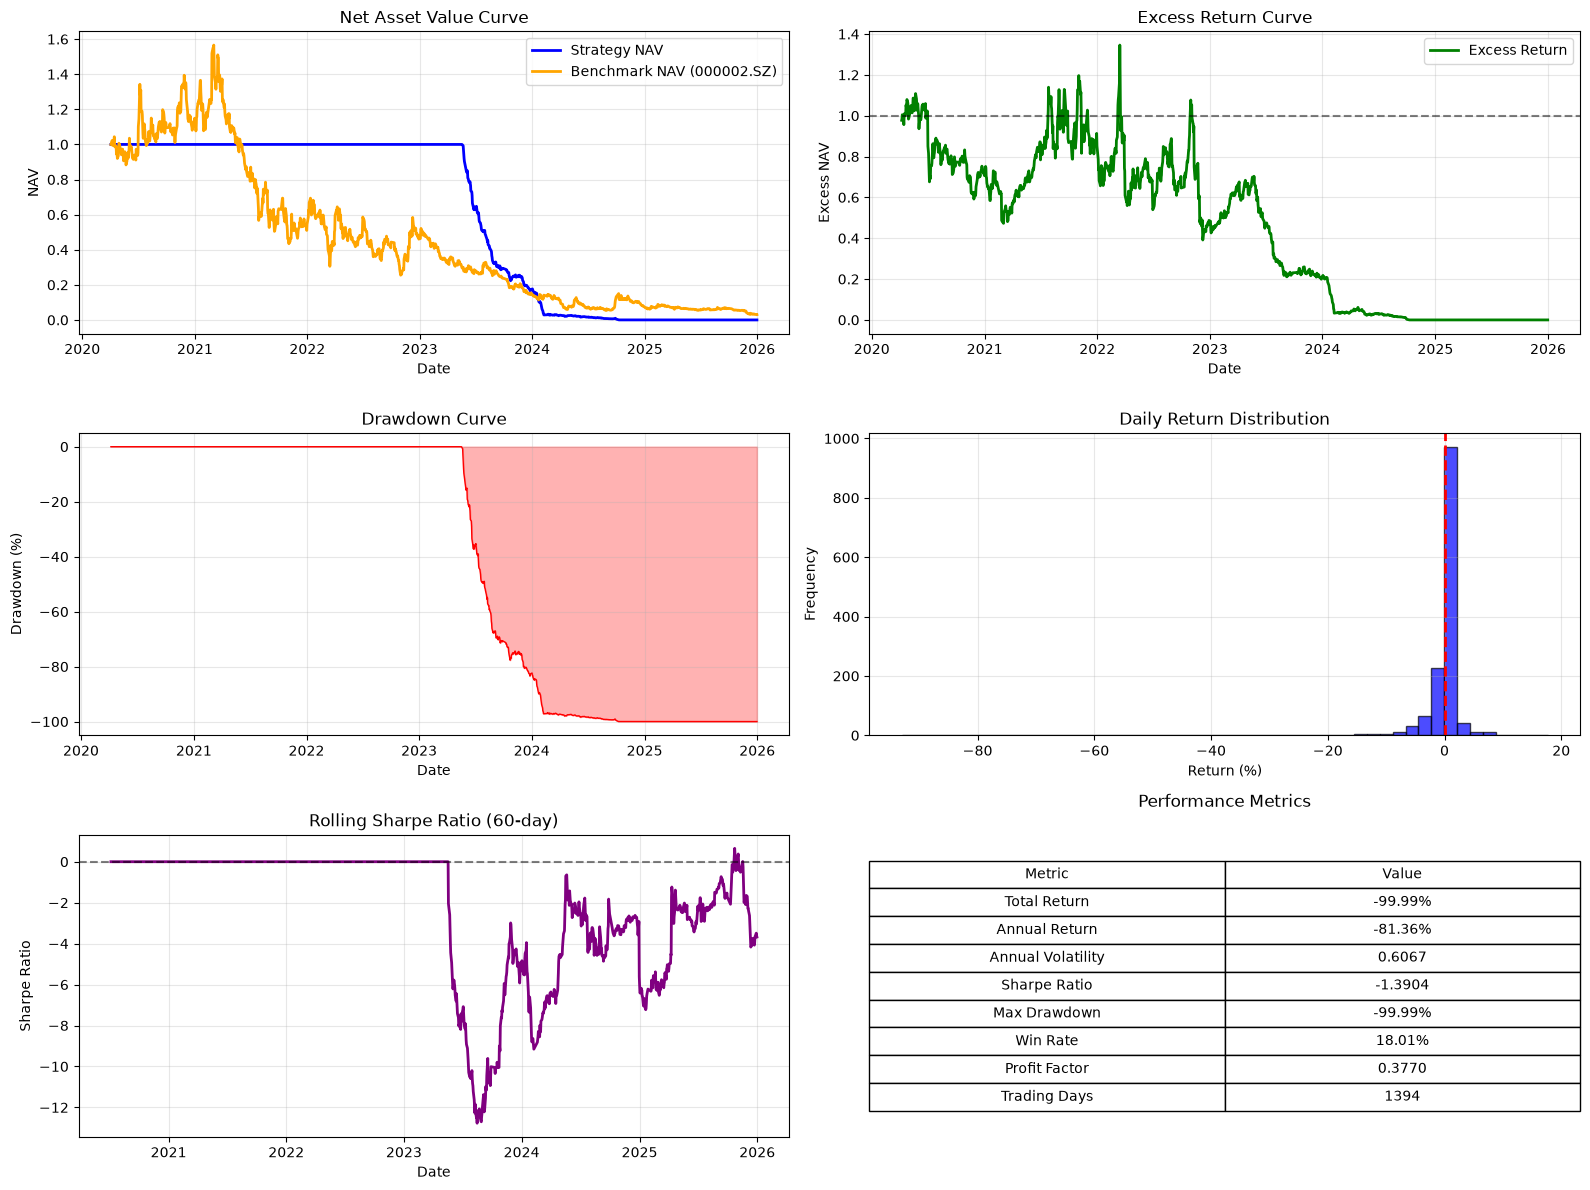


所有结果已保存至: d:\a111111\回测模拟\data_process\model_results\lasso
✅ 回测完成

测试模型: rf
开始 rf 滚动预测...

开始滚动预测...
模型类型: rf
训练窗口: 756 天
重训练频率: 63 天
因子数量: 54
总交易日: 1395

训练窗口: 2020-04-03 00:00:00 到 2023-05-17 00:00:00
预测日期: 2023-05-18 00:00:00
训练样本数: 116659
训练集 RMSE: 0.058104, R2: 0.0876
验证集 RMSE: 0.081454, R2: 0.0115
预测完成，共 180 个样本

训练窗口: 2020-07-09 00:00:00 到 2023-08-16 00:00:00
预测日期: 2023-08-17 00:00:00
训练样本数: 119590
训练集 RMSE: 0.057268, R2: 0.0858
验证集 RMSE: 0.081135, R2: 0.0142
预测完成，共 181 个样本

训练窗口: 2020-10-14 00:00:00 到 2023-11-21 00:00:00
预测日期: 2023-11-22 00:00:00
训练样本数: 122600
训练集 RMSE: 0.055920, R2: 0.0870
验证集 RMSE: 0.080866, R2: 0.0110
预测完成，共 186 个样本

训练窗口: 2021-01-12 00:00:00 到 2024-02-27 00:00:00
预测日期: 2024-02-28 00:00:00
训练样本数: 125629
训练集 RMSE: 0.056096, R2: 0.0968
验证集 RMSE: 0.078961, R2: 0.0147
预测完成，共 187 个样本

训练窗口: 2021-04-19 00:00:00 到 2024-05-31 00:00:00
预测日期: 2024-06-03 00:00:00
训练样本数: 128405
训练集 RMSE: 0.056331, R2: 0.0933
验证集 RMSE: 0.078692, R2: 0.0192
预测完成，共 188 个样本

训练窗口: 2021-07-

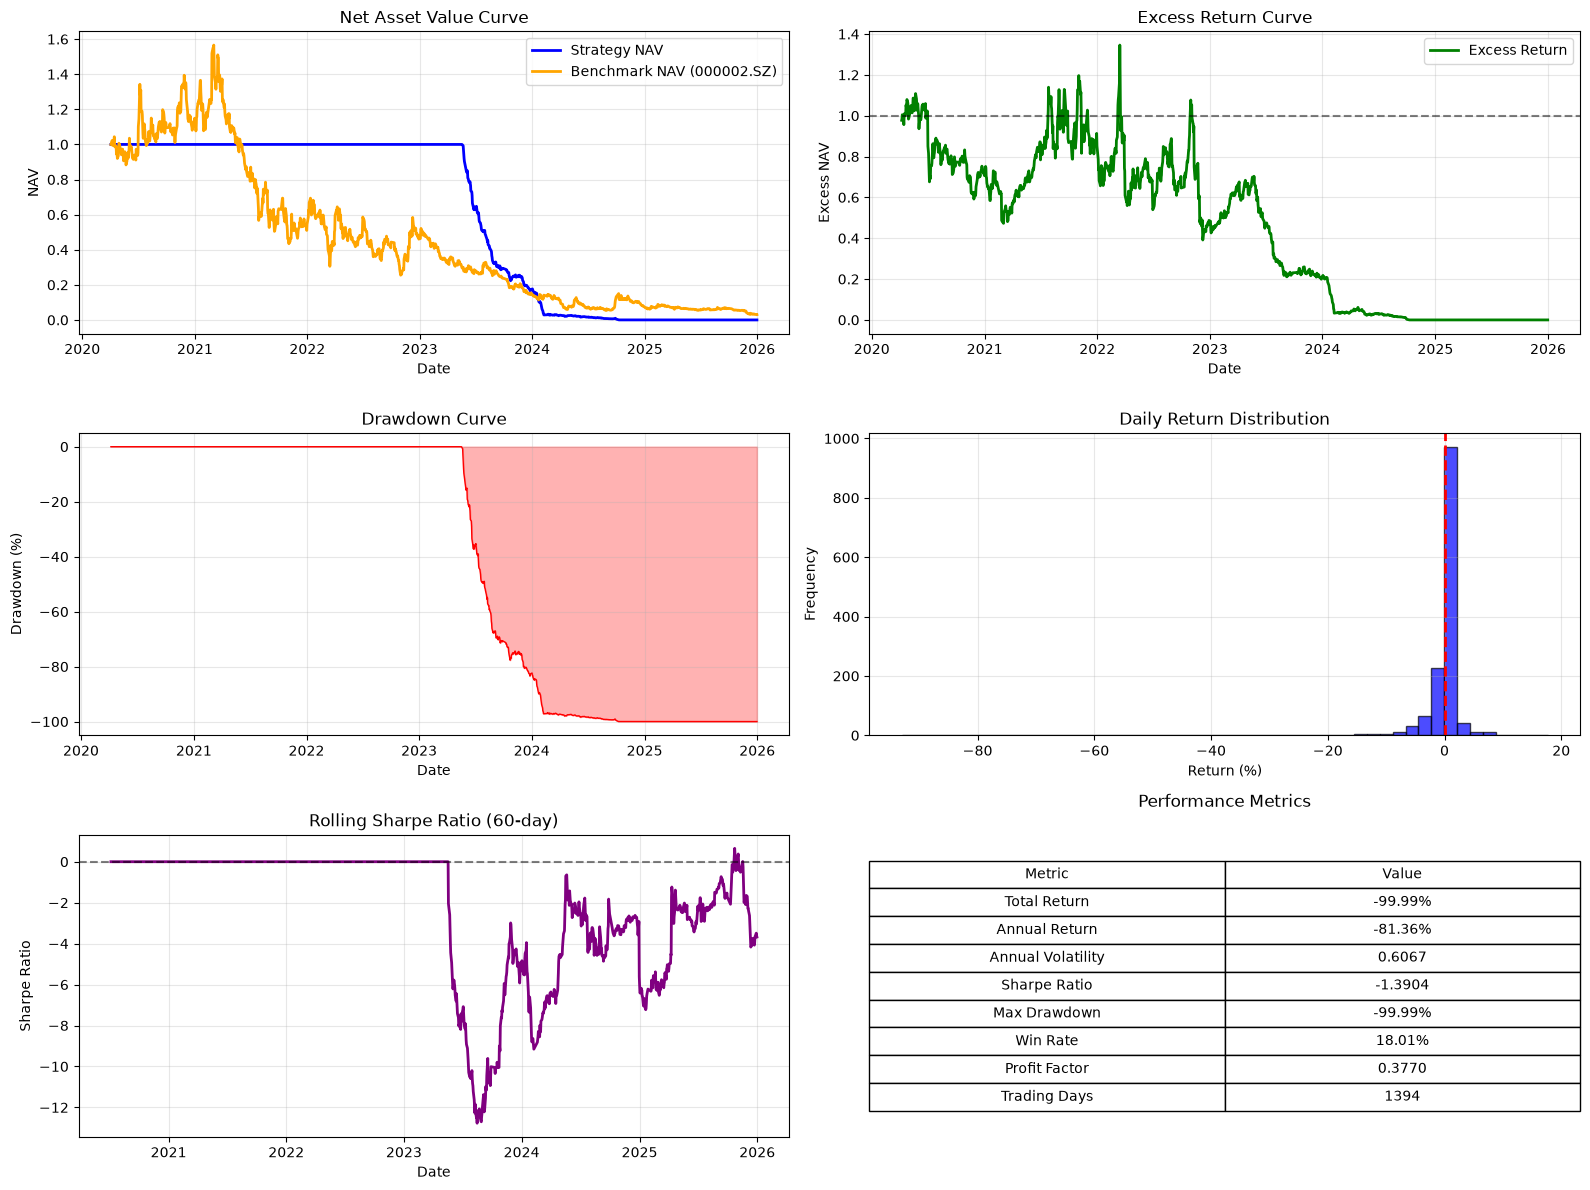


交易记录已保存: d:\a111111\回测模拟\data_process\model_results\rf\composite_trade_records.csv
总交易次数: 1821
每日持仓已保存: d:\a111111\回测模拟\data_process\model_results\rf\composite_daily_holdings.csv
每日净值已保存: d:\a111111\回测模拟\data_process\model_results\rf\composite_daily_nav.csv
图表已保存: d:\a111111\回测模拟\data_process\model_results\rf\composite_factor_backtest_results.png


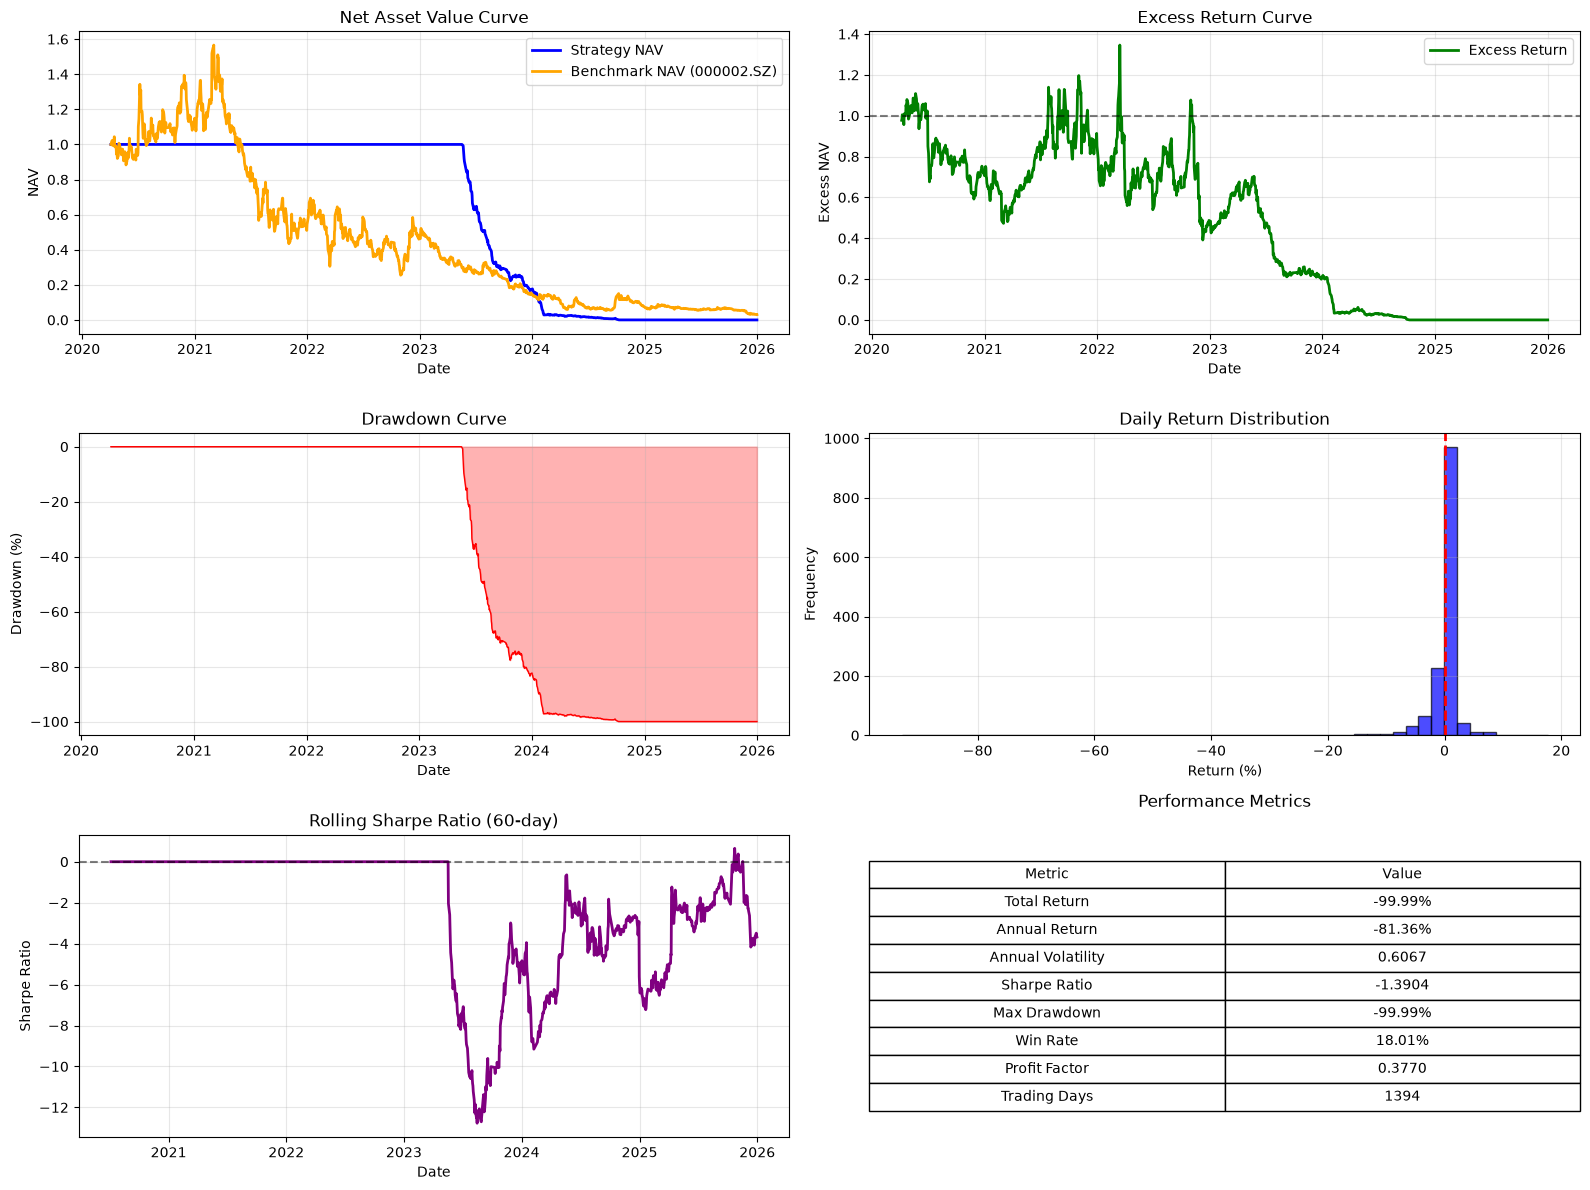


所有结果已保存至: d:\a111111\回测模拟\data_process\model_results\rf
✅ 回测完成

测试模型: gbdt
开始 gbdt 滚动预测...

开始滚动预测...
模型类型: gbdt
训练窗口: 756 天
重训练频率: 63 天
因子数量: 54
总交易日: 1395

训练窗口: 2020-04-03 00:00:00 到 2023-05-17 00:00:00
预测日期: 2023-05-18 00:00:00
训练样本数: 116659
训练集 RMSE: 0.057554, R2: 0.1048
验证集 RMSE: 0.080977, R2: 0.0230
预测完成，共 180 个样本

训练窗口: 2020-07-09 00:00:00 到 2023-08-16 00:00:00
预测日期: 2023-08-17 00:00:00
训练样本数: 119590
训练集 RMSE: 0.056709, R2: 0.1036
验证集 RMSE: 0.080817, R2: 0.0219
预测完成，共 181 个样本

训练窗口: 2020-10-14 00:00:00 到 2023-11-21 00:00:00
预测日期: 2023-11-22 00:00:00
训练样本数: 122600
训练集 RMSE: 0.055388, R2: 0.1043
验证集 RMSE: 0.080660, R2: 0.0160
预测完成，共 186 个样本

训练窗口: 2021-01-12 00:00:00 到 2024-02-27 00:00:00
预测日期: 2024-02-28 00:00:00
训练样本数: 125629
训练集 RMSE: 0.055524, R2: 0.1151
验证集 RMSE: 0.078996, R2: 0.0138
预测完成，共 187 个样本

训练窗口: 2021-04-19 00:00:00 到 2024-05-31 00:00:00
预测日期: 2024-06-03 00:00:00
训练样本数: 128405
训练集 RMSE: 0.055419, R2: 0.1224
验证集 RMSE: 0.079153, R2: 0.0076
预测完成，共 188 个样本

训练窗口: 2021-

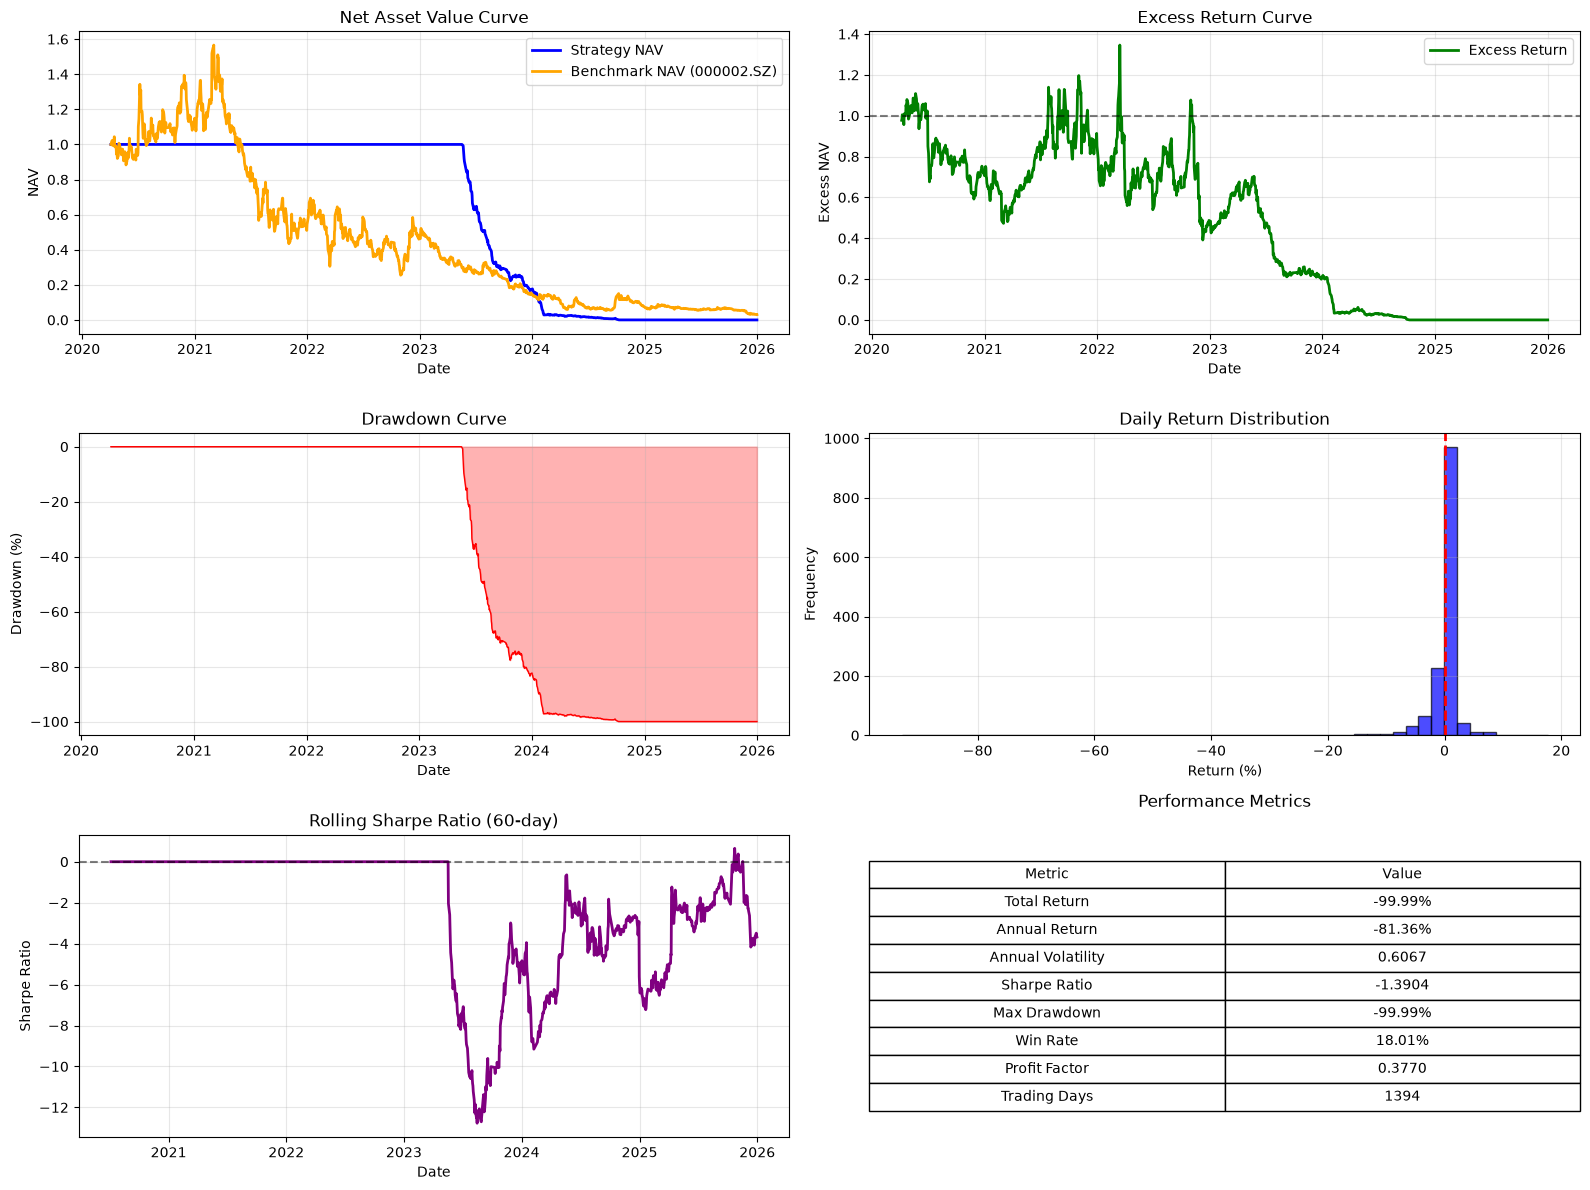


交易记录已保存: d:\a111111\回测模拟\data_process\model_results\gbdt\composite_trade_records.csv
总交易次数: 1821
每日持仓已保存: d:\a111111\回测模拟\data_process\model_results\gbdt\composite_daily_holdings.csv
每日净值已保存: d:\a111111\回测模拟\data_process\model_results\gbdt\composite_daily_nav.csv
图表已保存: d:\a111111\回测模拟\data_process\model_results\gbdt\composite_factor_backtest_results.png


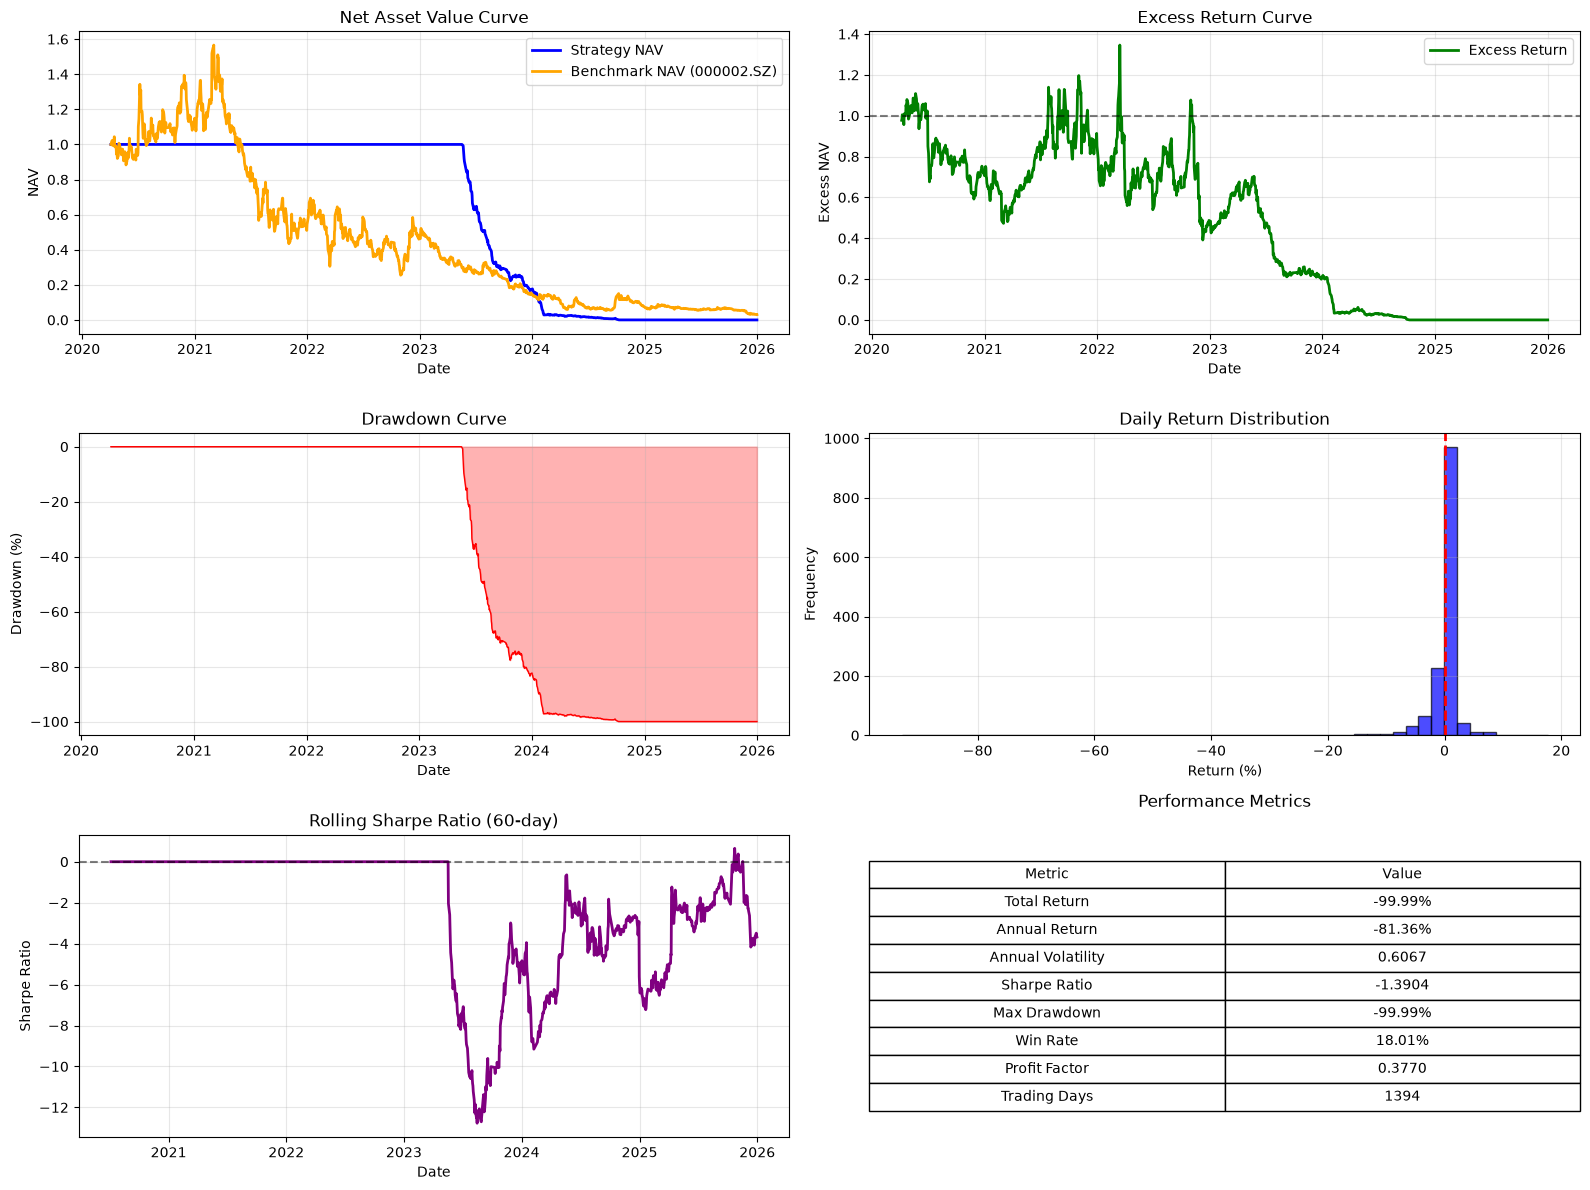


所有结果已保存至: d:\a111111\回测模拟\data_process\model_results\gbdt
✅ 回测完成

开始模型对比分析

模型对比分析

模型对比:
        total_return  annual_return  annual_volatility  sharpe_ratio  \
model                                                                  
linear       -0.9999        -0.8136             0.6067       -1.3904   
ridge        -0.9999        -0.8136             0.6067       -1.3904   
lasso        -0.9999        -0.8136             0.6067       -1.3904   
rf           -0.9999        -0.8136             0.6067       -1.3904   
gbdt         -0.9999        -0.8136             0.6067       -1.3904   

        max_drawdown  trading_days  
model                               
linear       -0.9999          1394  
ridge        -0.9999          1394  
lasso        -0.9999          1394  
rf           -0.9999          1394  
gbdt         -0.9999          1394  

✅ 对比结果已保存: d:\a111111\回测模拟\data_process\model_results\model_comparison.csv

模型性能对比:
        total_return  annual_return  annual_volatility  shar

In [20]:
def main():
    """主程序"""
    print("="*80)
    print("多因子合成与回测系统")
    print("="*80)
    
    # 获取当前工作目录
    current_dir = os.getcwd()
    print(f"当前工作目录: {current_dir}")
    
    # 构建数据路径 - 相对于当前工作目录
    DATA_PATH = os.path.join(current_dir, '..', 'final_data')
    OUTPUT_PATH = os.path.join(current_dir, 'model_results')
    
    # 如果上述路径不存在，尝试从脚本所在目录查找
    if not os.path.exists(DATA_PATH):
        script_dir = os.path.dirname(os.path.abspath(__file__))
        DATA_PATH = os.path.join(script_dir, '..', 'final_data')
        OUTPUT_PATH = os.path.join(script_dir, 'model_results')
        print(f"使用脚本目录: {script_dir}")
    
    # 标准化路径
    DATA_PATH = os.path.normpath(DATA_PATH)
    OUTPUT_PATH = os.path.normpath(OUTPUT_PATH)
    
    print(f"数据路径: {DATA_PATH}")
    print(f"输出路径: {OUTPUT_PATH}")
    
    # 检查数据路径是否存在
    if not os.path.exists(DATA_PATH):
        print(f"❌ 错误: 数据路径不存在 - {DATA_PATH}")
        print("请检查数据文件是否在正确的位置")
        return
    
    # 创建输出目录
    os.makedirs(OUTPUT_PATH, exist_ok=True)
    
    # 加载数据
    try:
        print("正在加载数据...")
        processor = DataProcessor(DATA_PATH)
        df = processor.load_data()
        print(f"✅ 数据加载成功，形状: {df.shape}")
    except Exception as e:
        print(f"❌ 数据加载失败: {e}")
        import traceback
        traceback.print_exc()
        return
    
    # 检查是否有因子列
    if len(processor.factor_cols) == 0:
        print("❌ 错误: 没有找到因子列")
        print("数据列: ", df.columns.tolist()[:20])
        return
    
    print(f"可用因子数量: {len(processor.factor_cols)}")
    print(f"因子列 (前10个): {processor.factor_cols[:10]}...")
    
    # 检查数据量
    print(f"数据总行数: {len(df):,}")
    print(f"股票数量: {df['ts_code'].nunique()}")
    print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
    
    # 定义要测试的模型
    models_to_test = ['linear', 'ridge', 'lasso', 'rf', 'gbdt']
    
    # 如果数据量较小，减少模型数量
    if len(df) < 10000:
        print("数据量较小，减少模型测试数量")
        models_to_test = ['linear', 'rf']
    
    print(f"将测试的模型: {models_to_test}")
    
    all_results = {}
    
    # 对每个模型进行训练和回测
    for model_name in models_to_test:
        print("\n" + "="*80)
        print(f"测试模型: {model_name}")
        print("="*80)
        
        try:
            # 滚动预测
            print(f"开始 {model_name} 滚动预测...")
            predictor = RollingPredictor(df, model_type=model_name, n_jobs=min(4, os.cpu_count() or 1))
            predictions = predictor.rolling_train_predict()
            
            if predictions.empty:
                print(f"⚠️ {model_name} 预测结果为空，跳过")
                continue
            
            print(f"✅ {model_name} 预测完成，预测结果数量: {len(predictions)}")
            
            # 合成因子
            print(f"开始合成因子...")
            combiner = FactorCombiner(df, predictions)
            combined_data = combiner.combine_factors()
            print(f"✅ 因子合成完成，数据形状: {combined_data.shape}")
            
            # 运行回测
            print(f"开始运行回测...")
            output_dir = os.path.join(OUTPUT_PATH, model_name)
            backtest = run_composite_factor_backtest(combined_data, 'composite_factor', output_dir)
            print(f"✅ 回测完成")
            
            # 保存结果
            all_results[model_name] = backtest.results if hasattr(backtest, 'results') else None
            
        except Exception as e:
            print(f"❌ 模型 {model_name} 运行失败: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # 对比分析
    if all_results:
        print("\n" + "="*80)
        print("开始模型对比分析")
        print("="*80)
        
        comparator = ResultComparator(all_results)
        comparison_df = comparator.compare()
        
        if comparison_df is not None and not comparison_df.empty:
            comparison_df.to_csv(os.path.join(OUTPUT_PATH, 'model_comparison.csv'))
            print(f"\n✅ 对比结果已保存: {os.path.join(OUTPUT_PATH, 'model_comparison.csv')}")
            
            # 打印对比结果
            print("\n模型性能对比:")
            print(comparison_df.to_string())
        else:
            print("⚠️ 对比结果为空")
    else:
        print("❌ 没有成功的模型结果")
    
    print("\n" + "="*80)
    print("所有模型测试完成！")
    print("="*80)

# ==================== 添加调试入口 ====================
if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"程序运行异常: {e}")
        import traceback
        traceback.print_exc()
        input("按Enter键退出...")